In [1]:
import pandas as pd
from cartopy import crs as ccrs
import xarray as xr
from xhistogram.xarray import histogram
import numpy as np
# import gfdl_utils as gu
import glob
import re
from scipy.interpolate import griddata
import geopy
import cmocean.cm as cmo
import cmocean
import gsw
from geopy import distance
import xesmf as xe
# import sectionate
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150


In [2]:
# GLODAP:model variable naming conventions
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'},
    'cfc11':{'conversion':1e12/1035,'cmap':cmo.matter_r,'units':r'pmol kg$^{-1}$'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK'},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'ct':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'sa':{'conversion':1,'cmap':cmocean.cm.haline,'units':r'g kg$^{-1}$'},
    'so':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'}, 
    'density':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},
    'rho2':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},

    'agessc':{'conversion':1,'cmap':cmocean.cm.speed,'units':'years'}
}

In [5]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/" + x
ds = xr.open_dataset(datadir("PAC_Tracer_Hov_on_Z.nc")).astype("float32")
ds = ds.rename({"z_l":"z"}).groupby("time.year").mean("time")
ds["ct"] = ds["ct"] - ds["ct"].mean("year")
ds.coords["z"] = -ds["z"].values

getfattr: /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/PAC_Tracer_Hov_on_Z.nc: Operation not supported


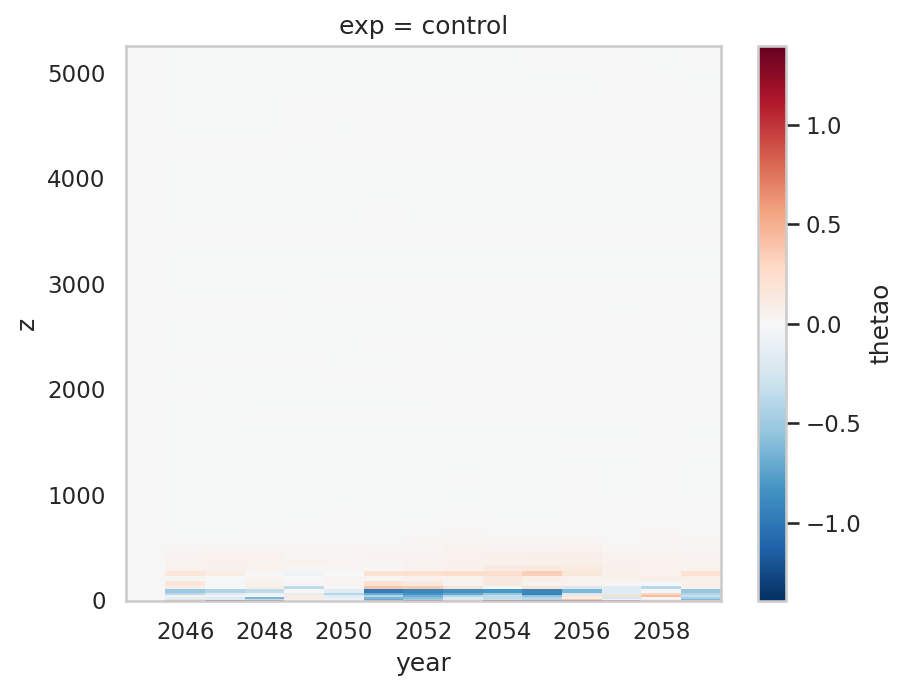

In [6]:
(ds["thetao"].sel(exp = "control") - ds["thetao"].sel(exp = "control").isel(year = 0)).T.plot()

In [9]:
from scipy.interpolate import interp1d

# Define sigma levels from year 0
ctrl_levels = np.unique(ds.rho2.sel(exp="control").isel(year=0))
forced_levels = np.unique(ds.rho2.sel(exp="forced").isel(year=0))

siglevels = np.sort(np.unique(np.concatenate([ctrl_levels, forced_levels])))
siglevels = siglevels[~np.isnan(siglevels)]

# Target depth grid (from original ds)
target_depths = ds.z.values

# Pre-allocate output for spice signal
ct_spice = np.full((len(ds.year), len(ds.exp), len(target_depths)), np.nan)

# Process each profile
for i in range(len(ds.year)):
    for j, exp in enumerate(ds.exp):
        # Get this profile
        rho_profile = ds.rho2.isel(year=i, exp=j).values
        ct_profile = ds.ct.isel(year=i, exp=j).values
        z_profile = ds.z.values
        
        # Remove NaNs - only use finite values
        valid = np.isfinite(rho_profile) & np.isfinite(ct_profile)
        if valid.sum() < 2:
            continue
            
        rho_valid = rho_profile[valid]
        ct_valid = ct_profile[valid]
        z_valid = z_profile[valid]
        
        # Sort by density to make monotonic
        sort_idx = np.argsort(rho_valid)
        rho_sorted = rho_valid[sort_idx]
        ct_sorted = ct_valid[sort_idx]
        z_sorted = z_valid[sort_idx]
        
        # Step 1: Interpolate onto sigma levels
        f_ct = interp1d(rho_sorted, ct_sorted, kind='linear', 
                        bounds_error=False, fill_value=np.nan)
        f_depth = interp1d(rho_sorted, z_sorted, kind='linear',
                           bounds_error=False, fill_value=np.nan)
        
        ct_on_sigma = f_ct(siglevels)
        depth_on_sigma = f_depth(siglevels)
        
        # Remove NaNs from sigma-coordinate data
        valid_sigma = np.isfinite(ct_on_sigma) & np.isfinite(depth_on_sigma)
        if valid_sigma.sum() < 2:
            continue
        
        ct_sigma_valid = ct_on_sigma[valid_sigma]
        depth_sigma_valid = depth_on_sigma[valid_sigma]
        
        # Sort by depth to make monotonic for interpolation back to z
        sort_idx_depth = np.argsort(depth_sigma_valid)
        ct_sigma_sorted = ct_sigma_valid[sort_idx_depth]
        depth_sigma_sorted = depth_sigma_valid[sort_idx_depth]
        
        # Step 2: Interpolate back onto target depth grid
        f_ct_back = interp1d(depth_sigma_sorted, ct_sigma_sorted, kind='linear',
                             bounds_error=False, fill_value=np.nan)
        
        ct_spice[i, j, :] = f_ct_back(target_depths)

# Create spice signal dataset
spice_signal = xr.Dataset(
    {
        'ct': (['year', 'exp', 'z'], ct_spice),
    },
    coords={
        'year': ds.year,
        'exp': ds.exp,
        'z': target_depths,
    }
)

In [13]:
heave_signal = ds["ct"] - spice_signal

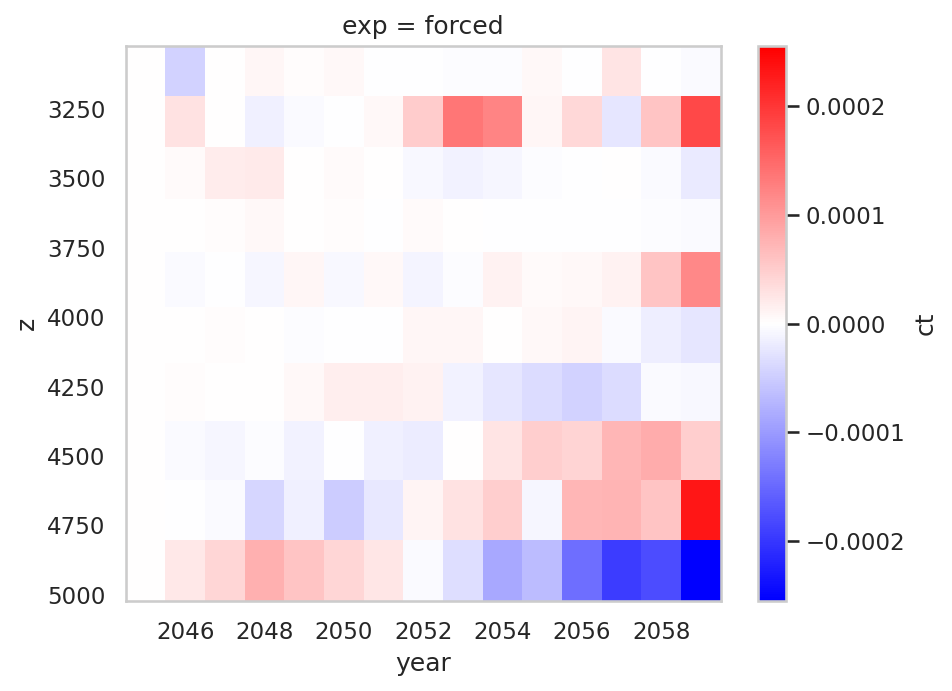

In [15]:
heave_signal.sel(exp = "forced").ct.sel(z = slice(5000, 3000)).T.plot(yincrease = False, cmap = "bwr")

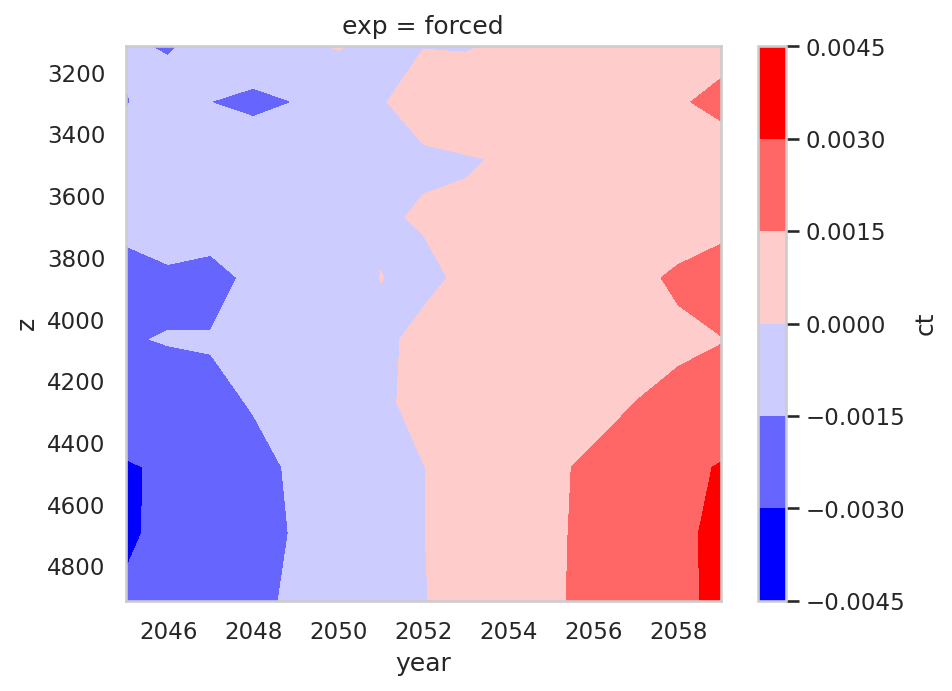

In [16]:
spice_signal.sel(exp = "forced").ct.sel(z = slice(5000, 3000)).T.plot.contourf(yincrease = False, cmap = "bwr")

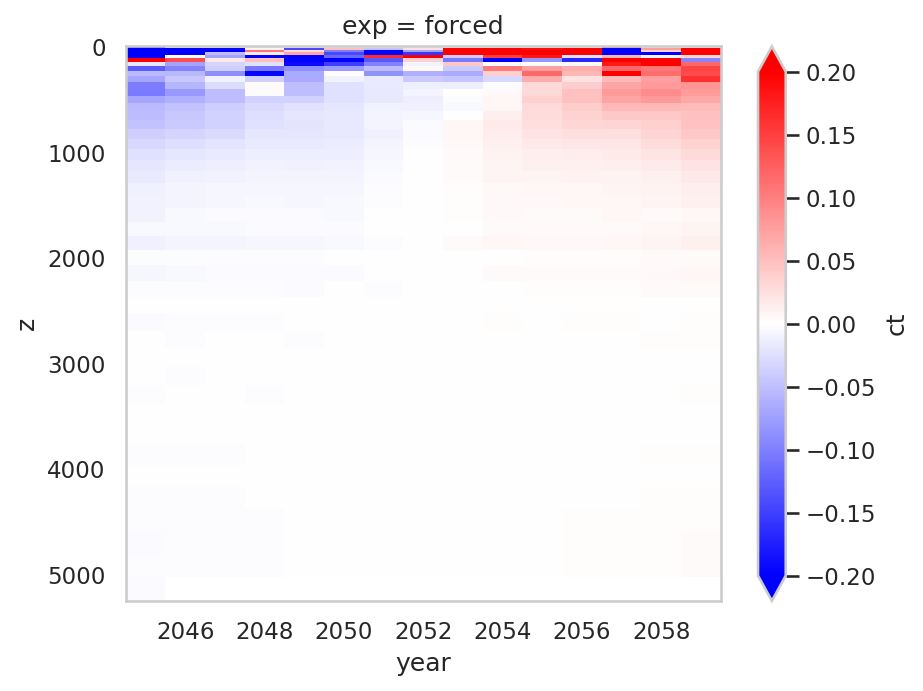

In [12]:
spice_signal.sel(exp = "forced").ct.T.plot(yincrease = False, vmin = -0.2, vmax = 0.2, cmap = "bwr")

Max heaving contribution: 0.02881570352070245


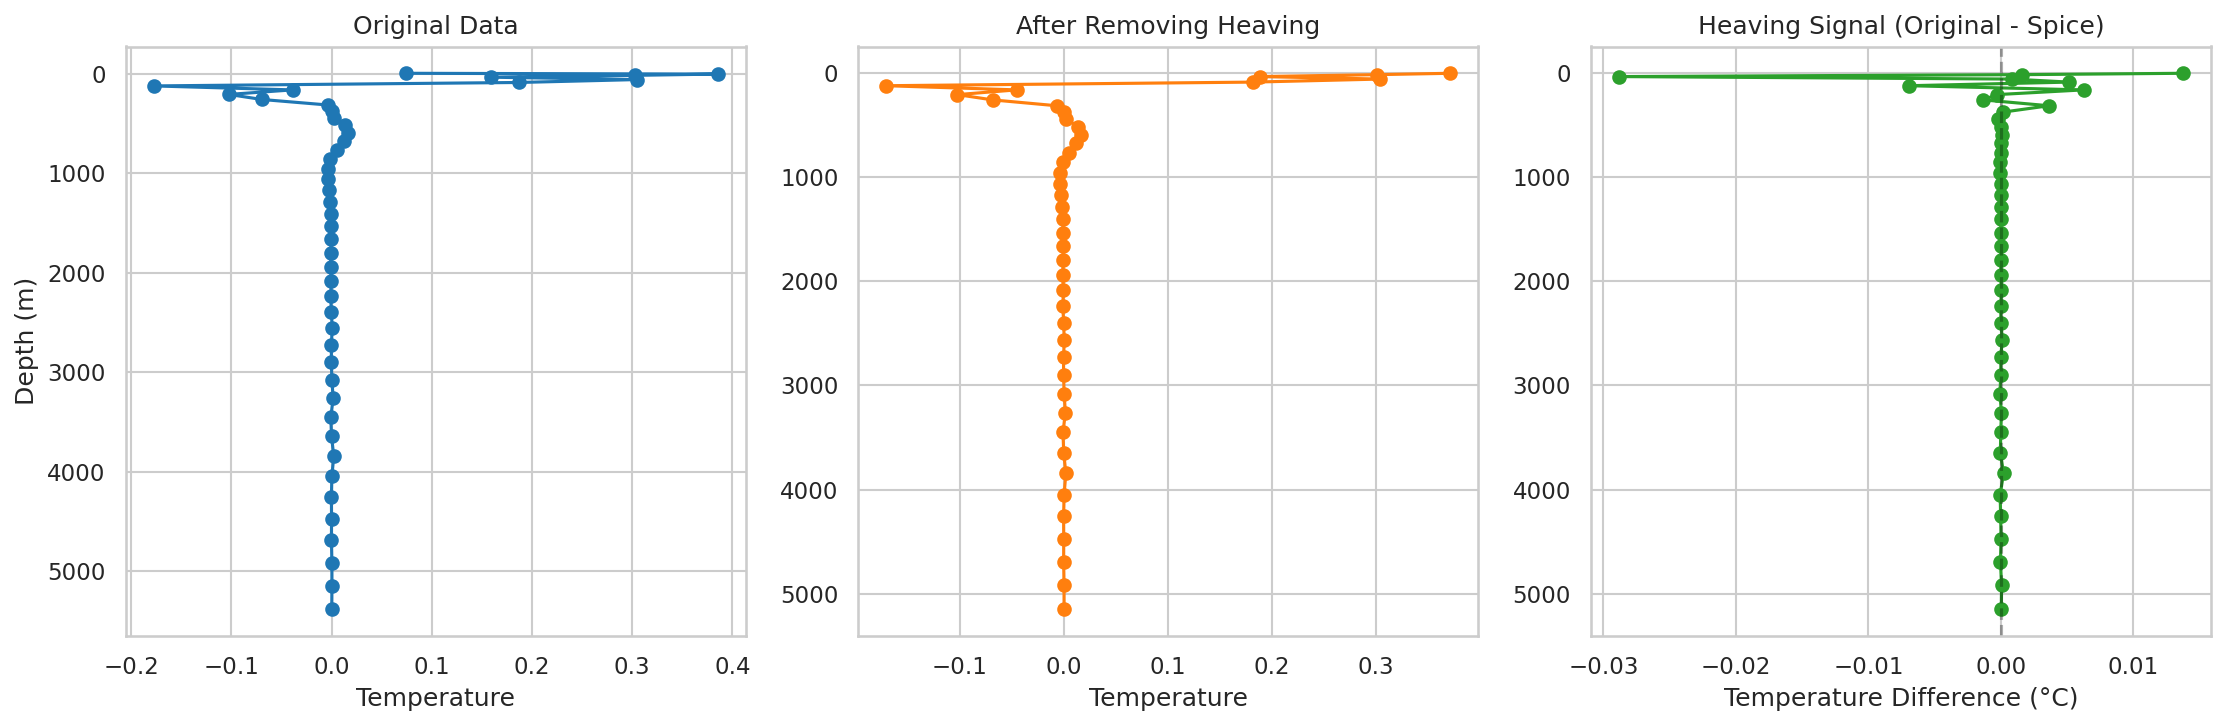

In [19]:
# Original data (NOT sorted)
ct_original = ds.ct.isel(year=10).sel(exp='control')

# After removing heaving (spice signal)
ct_spice = spice_signal.ct.isel(year=10).sel(exp='control')

# The difference shows the heaving contribution
heaving_signal = ct_original - ct_spice

print("Max heaving contribution:", np.abs(heaving_signal).max().values)

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(ct_original, ds.z, 'o-', label='Original')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Original Data')
axes[0].invert_yaxis()

axes[1].plot(ct_spice, spice_signal.z, 'o-', label='Spice Signal', color='C1')
axes[1].set_xlabel('Temperature')
axes[1].set_title('After Removing Heaving')
axes[1].invert_yaxis()

axes[2].plot(heaving_signal, ds.z, 'o-', color='C2')
axes[2].set_xlabel('Temperature Difference (°C)')
axes[2].set_title('Heaving Signal (Original - Spice)')
axes[2].invert_yaxis()
axes[2].axvline(0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Max heaving contribution: 0.016189459258244082


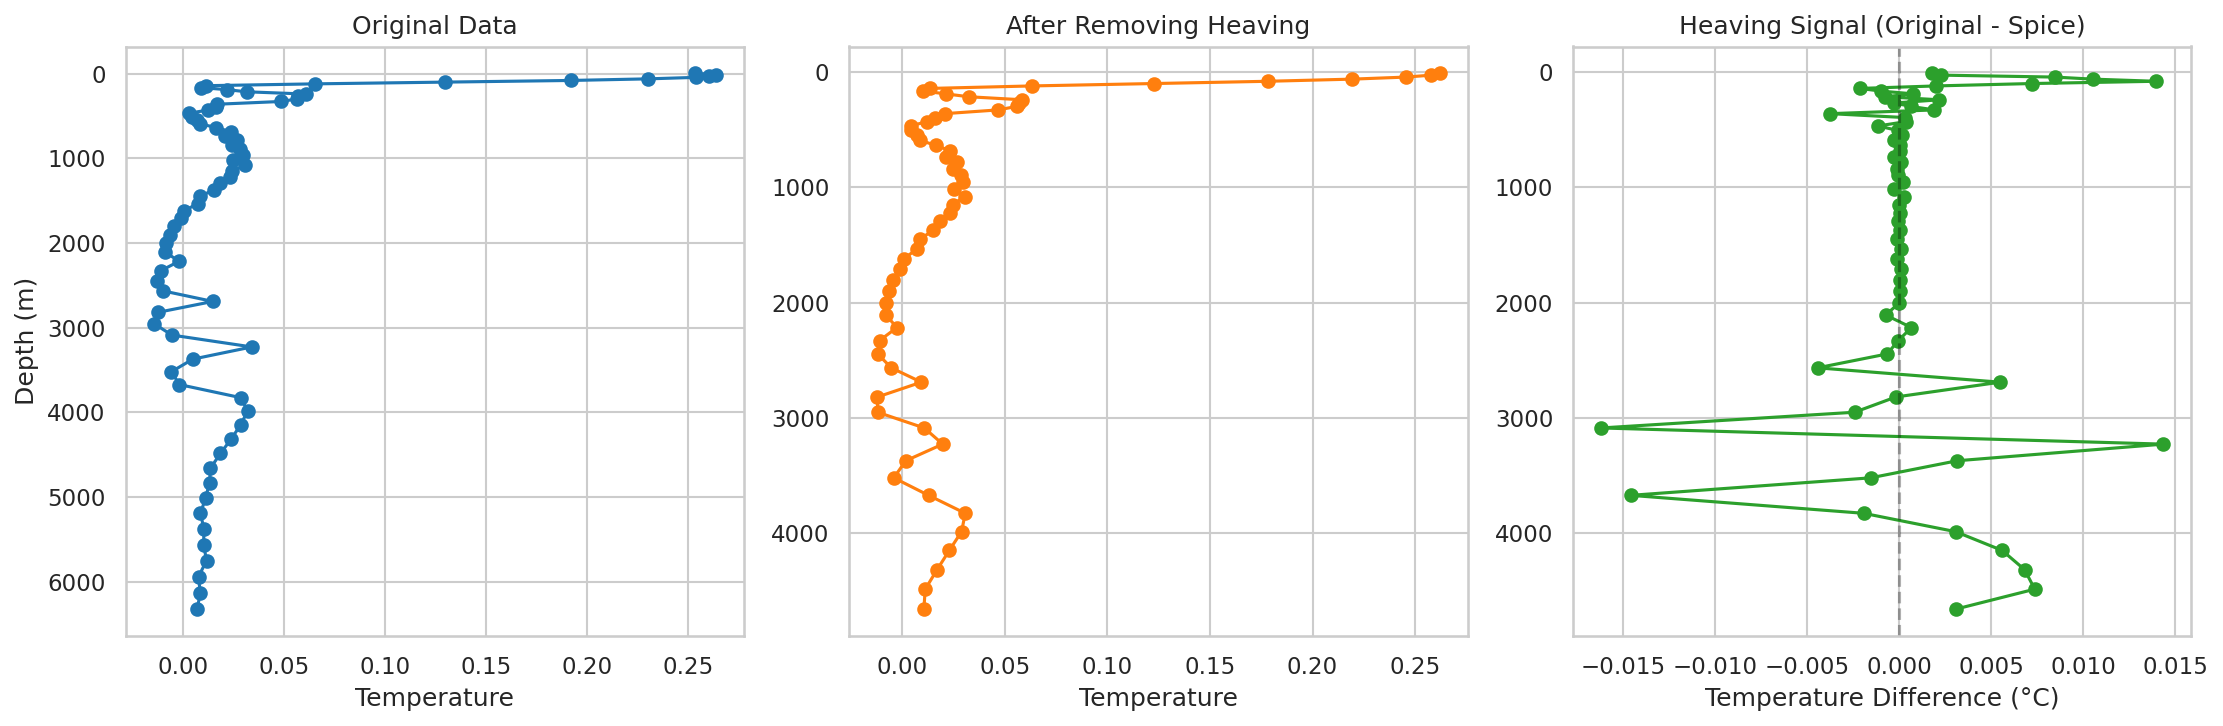

In [21]:
# Original data (NOT sorted)
ct_original = ds.ct.isel(year=10).sel(exp='control')

# After removing heaving (spice signal)
ct_spice = spice_signal.ct.isel(year=10).sel(exp='control')

# The difference shows the heaving contribution
heaving_signal = ct_original - ct_spice

print("Max heaving contribution:", np.abs(heaving_signal).max().values)

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(ct_original, ds.z, 'o-', label='Original')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Original Data')
axes[0].invert_yaxis()

axes[1].plot(ct_spice, spice_signal.z, 'o-', label='Spice Signal', color='C1')
axes[1].set_xlabel('Temperature')
axes[1].set_title('After Removing Heaving')
axes[1].invert_yaxis()

axes[2].plot(heaving_signal, ds.z, 'o-', color='C2')
axes[2].set_xlabel('Temperature Difference (°C)')
axes[2].set_title('Heaving Signal (Original - Spice)')
axes[2].invert_yaxis()
axes[2].axvline(0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Check vertical temperature gradient around rho=36.9
ct_profile = ds.ct.isel(year=10).sel(exp='control')
z_vals = ds.z.values
valid = ~np.isnan(ct_profile)

# Compute gradient
dct_dz = np.gradient(ct_profile.values[valid], z_vals[valid])
print(f"Temperature gradient around 3300m: ~{dct_dz[40]:.6f} °C/m")
print(f"Expected temperature change from 30m heaving: ~{abs(dct_dz[40] * 30):.3f} °C")

Temperature gradient around 3300m: ~0.000005 °C/m
Expected temperature change from 30m heaving: ~0.000 °C


In [20]:
fig, ax = plt.subplots(1, 2, figsize = (7, 6.5), sharey = True)
levels = np.arange(-1, 5, 0.5)
tracer = "ct"; tracername = "Conservative Temperature"
fig.suptitle(f"Southern Ocean {tracername} (CM4X 0.125°)")

def plot_temperature(ds, ax, tracer, levels, siglevels): 
    tmp1 = ds[[tracer, "rho2"]]
    cntf = ax.contourf(tmp1.year, tmp1.z, tmp1[tracer].T, cmap = cmo.deep, extend = "both", levels = levels)
    cnt = ax.contour(tmp1.year, tmp1.z, tmp1.rho2.T, levels = siglevels, colors = "white");
    cs = ax.clabel(cnt, inline=True, fontsize=10)
    return cntf, cnt, cs

cntf, cnt, cs = plot_temperature(ds.sel(exp = "control"), ax[0], tracer, levels, siglevels)
ax[0].set_ylabel("Depth [meters]")
ax[0].set_xlabel("time [years]")
ax[0].set_title("Control")

cntf, cnt, cs = plot_temperature(ds.sel(exp = "forced"), ax[1], tracer, levels, siglevels)
# ax[1].set_yticklabels([])
ax[1].set_title("Forced")
ax[1].set_xlabel("time [years]")

[a.set_facecolor("#3A3B3C") for a in ax]
[a.grid(alpha = 0) for a in ax]
[a.set_ylim(-7000, -0) for a in ax]
[a.tick_params(bottom=True, left=True) for a in ax.flatten()];

cbar = fig.colorbar(cntf, ax = ax[0:2], label = f"[{variable_kwargs[tracer]["units"]}]", 
                    orientation = "horizontal", fraction = 0.03)
cbar.ax.tick_params(rotation=45)

# fig.savefig(plotsdir("paper_figures/SouthernOceanTemperature.png"), bbox_inches = "tight", dpi = 100)

SyntaxError: f-string: unmatched '[' (669467616.py, line 28)